In [2]:
#Load the Dataset

import pandas as pd
import numpy as np

df = pd.read_csv('lecture_engagement_pattern_analyzer.csv')



In [3]:
df.head()

,student_id,study_level,video_completion_pct,lecture_duration_min,pause_count,rewatch_count,quiz_attempts,quiz_score_pct,notes_taken,questions_asked,login_delay_min,sessions_per_week,screen_time_hours,completion_ratio,quiz_efficiency,engagement_score,performance_category,next_quiz_score,reference_behavior_group
0,S1001,Medium,79.7,45.5,1,0,4,49.0,No,1,3.2,4,4.6,0.797,12.24,66.9,Medium,56.2,Quiz-focused learners
1,S1002,Very Good,91.1,44.6,5,1,2,61.2,Yes,0,3.4,5,6.2,0.911,30.62,73.9,Medium,80.8,Complete learners
2,S1003,Good,90.7,22.7,0,5,1,43.6,No,0,4.0,6,3.6,0.907,43.61,80.5,Good,47.1,Rewatch learners
3,S1004,Good,94.9,40.7,7,1,1,69.7,Sometimes,1,11.8,3,4.4,0.949,69.70,42.1,Low,74.8,Mixed learners
4,S1005,Low,71.6,26.0,5,2,2,39.7,Sometimes,2,15.2,1,4.5,0.716,19.86,13.0,Poor,45.5,Last-minute learners


In [4]:
print("Number of Columns and Rows: ", df.shape)
print("\n")
print("Columns Names and Types :  ")
df.info()

Number of Columns and Rows:  (500, 19)


Columns Names and Types :  
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                500 non-null    str    
 1   study_level               500 non-null    str    
 2   video_completion_pct      500 non-null    float64
 3   lecture_duration_min      500 non-null    float64
 4   pause_count               500 non-null    int64  
 5   rewatch_count             500 non-null    int64  
 6   quiz_attempts             500 non-null    int64  
 7   quiz_score_pct            500 non-null    float64
 8   notes_taken               500 non-null    str    
 9   questions_asked           500 non-null    int64  
 10  login_delay_min           500 non-null    float64
 11  sessions_per_week         500 non-null    int64  
 12  screen_time_hours         500 non-null    float64
 13  complet

In [5]:
df.describe()

,video_completion_pct,lecture_duration_min,pause_count,rewatch_count,quiz_attempts,quiz_score_pct,questions_asked,login_delay_min,sessions_per_week,screen_time_hours,completion_ratio,quiz_efficiency,engagement_score,next_quiz_score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,77.046600,40.241200,4.958000,2.676000,2.516000,54.818000,1.460000,8.16880,4.474000,4.421200,0.770466,28.055620,58.333200,63.102800
std,15.632144,11.471604,2.801416,1.821444,1.156035,10.947347,1.176081,6.13994,2.035094,1.785824,0.156321,16.498002,21.232348,11.641639
min,34.600000,20.100000,0.000000,0.000000,1.000000,24.700000,0.000000,0.00000,1.000000,0.500000,0.346000,6.010000,0.000000,32.000000
25%,65.400000,30.275000,3.000000,1.000000,2.000000,47.250000,1.000000,3.40000,3.000000,3.200000,0.654000,15.832500,43.675000,55.900000
50%,78.100000,40.900000,5.000000,3.000000,2.000000,54.950000,1.000000,7.55000,4.000000,4.400000,0.781000,22.565000,58.850000,63.300000
75%,90.450000,50.200000,7.000000,4.000000,3.000000,62.300000,2.000000,12.50000,6.000000,5.700000,0.904500,33.637500,73.700000,70.675000
max,100.000000,59.900000,14.000000,9.000000,7.000000,83.200000,6.000000,28.50000,11.000000,9.500000,1.000000,76.620000,100.000000,95.200000


In [6]:
print("Null values: ")
print(df.isnull().sum())
print("\nDuplicated: ",df.duplicated().sum())

Null values: 
student_id                  0
study_level                 0
video_completion_pct        0
lecture_duration_min        0
pause_count                 0
rewatch_count               0
quiz_attempts               0
quiz_score_pct              0
notes_taken                 0
questions_asked             0
login_delay_min             0
sessions_per_week           0
screen_time_hours           0
completion_ratio            0
quiz_efficiency             0
engagement_score            0
performance_category        0
next_quiz_score             0
reference_behavior_group    0
dtype: int64

Duplicated:  0


In [7]:
#Check target Distribution

print(df["performance_category"].value_counts())

performance_category
Poor         152
Low          124
Medium        98
Good          74
Very Good     52
Name: count, dtype: int64


In [8]:
# check impossible values

print(df[df["video_completion_pct"] > 100])

print(df[(df["quiz_score_pct"] > 100) | (df["quiz_score_pct"] < 0)])


Empty DataFrame
Columns: [student_id, study_level, video_completion_pct, lecture_duration_min, pause_count, rewatch_count, quiz_attempts, quiz_score_pct, notes_taken, questions_asked, login_delay_min, sessions_per_week, screen_time_hours, completion_ratio, quiz_efficiency, engagement_score, performance_category, next_quiz_score, reference_behavior_group]
Index: []
Empty DataFrame
Columns: [student_id, study_level, video_completion_pct, lecture_duration_min, pause_count, rewatch_count, quiz_attempts, quiz_score_pct, notes_taken, questions_asked, login_delay_min, sessions_per_week, screen_time_hours, completion_ratio, quiz_efficiency, engagement_score, performance_category, next_quiz_score, reference_behavior_group]
Index: []


***EDA process***


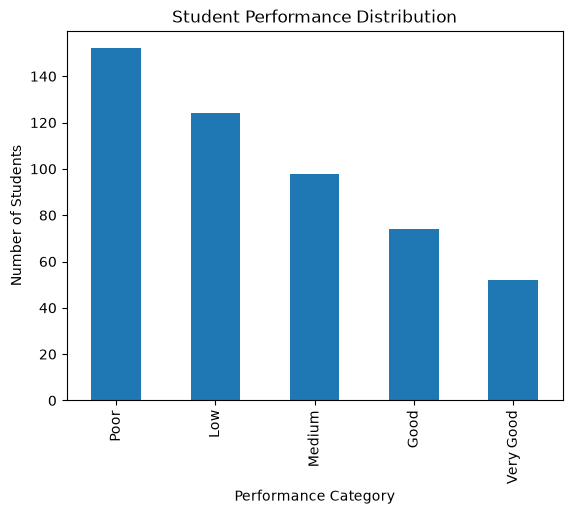

In [9]:

import matplotlib.pyplot as plt

df["performance_category"].value_counts().plot(kind="bar")

plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.title("Student Performance Distribution")
plt.show()


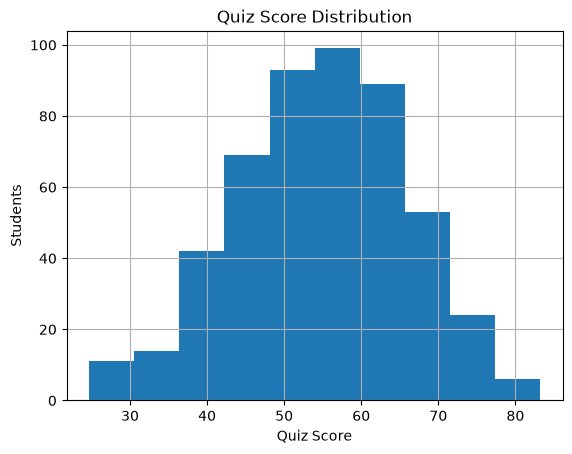

In [10]:
df["quiz_score_pct"].hist()

plt.xlabel("Quiz Score")
plt.ylabel("Students")
plt.title("Quiz Score Distribution")
plt.show()

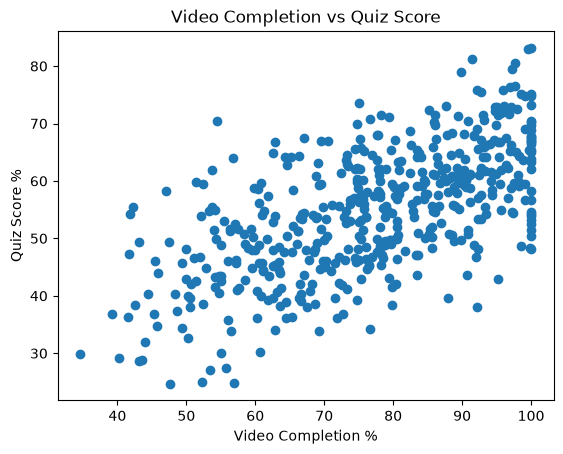

In [11]:
plt.scatter(
    df["video_completion_pct"],
    df["quiz_score_pct"]
)

plt.xlabel("Video Completion %")
plt.ylabel("Quiz Score %")
plt.title("Video Completion vs Quiz Score")
plt.show()


***Feature Engineering***

In [12]:
# Feature 1 — Completion ratio
df["completion_ratio"] = ( df["video_completion_pct"]/100)

# Feature 2 — Quiz efficiency
df["quiz_efficiency"] = ( df["quiz_score_pct"] / df["quiz_attempts"].replace(0,1))

# Feature 3 — Engagement score
df["engagement_score"] = (
    0.35 * df["video_completion_pct"]
    + 0.20 * df["quiz_score_pct"]
    + 8 * df["sessions_per_week"]
    + 5 * df["questions_asked"]
    - 2 * df["login_delay_min"]
    - 1.5 * df["pause_count"]
)

df["engagement_score"] = (
    df["engagement_score"].clip(0, 100)
)

***Feature Encoding***

In [13]:
df= pd.get_dummies(df, columns=["notes_taken"], drop_first=True)
df= pd.get_dummies(df, columns=["study_level"], drop_first=True)

In [14]:
df.head()

,student_id,video_completion_pct,lecture_duration_min,pause_count,rewatch_count,quiz_attempts,quiz_score_pct,questions_asked,login_delay_min,sessions_per_week,...,engagement_score,performance_category,next_quiz_score,reference_behavior_group,notes_taken_Sometimes,notes_taken_Yes,study_level_Low,study_level_Medium,study_level_Poor,study_level_Very Good
0,S1001,79.7,45.5,1,0,4,49.0,1,3.2,4,...,66.795,Medium,56.2,Quiz-focused learners,False,False,False,True,False,False
1,S1002,91.1,44.6,5,1,2,61.2,0,3.4,5,...,69.825,Medium,80.8,Complete learners,False,True,False,False,False,True
2,S1003,90.7,22.7,0,5,1,43.6,0,4.0,6,...,80.465,Good,47.1,Rewatch learners,False,False,False,False,False,False
3,S1004,94.9,40.7,7,1,1,69.7,1,11.8,3,...,42.055,Low,74.8,Mixed learners,True,False,False,False,False,False
4,S1005,71.6,26.0,5,2,2,39.7,2,15.2,1,...,13.100,Poor,45.5,Last-minute learners,True,False,True,False,False,False


In [15]:
df['notes_taken_Yes'] =df['notes_taken_Yes'].astype(int)
df['notes_taken_Sometimes'] =df['notes_taken_Sometimes'].astype(int)


In [16]:
df['study_level_Low'] =df['study_level_Low'].astype(int)
df['study_level_Medium'] =df['study_level_Medium'].astype(int)
df['study_level_Poor'] =df['study_level_Poor'].astype(int)
df['study_level_Very Good'] =df['study_level_Very Good'].astype(int)

In [17]:
df.head()

,student_id,video_completion_pct,lecture_duration_min,pause_count,rewatch_count,quiz_attempts,quiz_score_pct,questions_asked,login_delay_min,sessions_per_week,...,engagement_score,performance_category,next_quiz_score,reference_behavior_group,notes_taken_Sometimes,notes_taken_Yes,study_level_Low,study_level_Medium,study_level_Poor,study_level_Very Good
0,S1001,79.7,45.5,1,0,4,49.0,1,3.2,4,...,66.795,Medium,56.2,Quiz-focused learners,0,0,0,1,0,0
1,S1002,91.1,44.6,5,1,2,61.2,0,3.4,5,...,69.825,Medium,80.8,Complete learners,0,1,0,0,0,1
2,S1003,90.7,22.7,0,5,1,43.6,0,4.0,6,...,80.465,Good,47.1,Rewatch learners,0,0,0,0,0,0
3,S1004,94.9,40.7,7,1,1,69.7,1,11.8,3,...,42.055,Low,74.8,Mixed learners,1,0,0,0,0,0
4,S1005,71.6,26.0,5,2,2,39.7,2,15.2,1,...,13.100,Poor,45.5,Last-minute learners,1,0,1,0,0,0


***Separate x & y***

In [18]:
# Classification

y_class = df["performance_category"]

x_class = df.drop(
    columns=[
        "student_id",
        "performance_category",
        "next_quiz_score",
        "reference_behavior_group"
    ]
)


In [19]:
# Regression

y_reg = df["next_quiz_score"]

x_reg = df.drop(
    columns=[
        "student_id",
        "performance_category",
        "next_quiz_score",
        "reference_behavior_group"
    ]
)

***Train & Test Split***

In [20]:
from sklearn.model_selection import train_test_split

# for classification

x_train, x_test, y_train, y_test = train_test_split(x_class, y_class,test_size =0.2, random_state=42, stratify=y_class)


In [21]:
#for Regression

x_train_reg,x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

In [22]:
print("train value:",len(x_train))
print("test value:",len(x_test))

train value: 400
test value: 100


***Feature Scaling***

In [23]:
#Standardization

from sklearn.preprocessing import StandardScaler, MinMaxScaler

sc = StandardScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)


# MinMaxScaler
mms = MinMaxScaler()

x_train_mms = mms.fit_transform(x_train)
x_test_mms  = mms.transform(x_test)

***Classification Algorithms to test***

In [24]:
# Logistic Classification

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=2000)

#using standardized data
print("StandardScaler\n")
lr.fit(x_train_sc, y_train)

y_pred_lr_sc = lr.predict(x_test_sc)
print("acccuracy score of logistic Classification with standardized data:", accuracy_score(y_test, y_pred_lr_sc))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_sc))

print('\n')
#using MinMaxSclaer data
print("MinMaxScaler\n")
lr.fit(x_train_mms, y_train)

y_pred_lr_mms = lr.predict(x_test_mms)
print("acccuracy score of logistic Classification with standardized data:", accuracy_score(y_test, y_pred_lr_mms))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_mms))




StandardScaler

acccuracy score of logistic Classification with standardized data: 0.74
Classification Report:
               precision    recall  f1-score   support

        Good       0.53      0.67      0.59        15
         Low       0.74      0.80      0.77        25
      Medium       0.64      0.45      0.53        20
        Poor       0.90      0.93      0.92        30
   Very Good       0.78      0.70      0.74        10

    accuracy                           0.74       100
   macro avg       0.72      0.71      0.71       100
weighted avg       0.74      0.74      0.74       100



MinMaxScaler

acccuracy score of logistic Classification with standardized data: 0.61
Classification Report:
               precision    recall  f1-score   support

        Good       0.22      0.13      0.17        15
         Low       0.57      0.64      0.60        25
      Medium       0.47      0.40      0.43        20
        Poor       0.81      0.97      0.88        30
   Very Good    

In [25]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

#using standardized data
print("StandardScaler\n")
knn.fit(x_train_sc, y_train)

y_pred_lr_sc = knn.predict(x_test_sc)
print("acccuracy score of KNN with standardized data:", accuracy_score(y_test, y_pred_lr_sc))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_sc))

print('\n')
#using MinMaxSclaer data
print("MinMaxScaler\n")
knn.fit(x_train_mms, y_train)

y_pred_lr_mms = knn.predict(x_test_mms)
print("acccuracy score of KNN with standardized data:", accuracy_score(y_test, y_pred_lr_mms))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_mms))


StandardScaler

acccuracy score of KNN with standardized data: 0.43
Classification Report:
               precision    recall  f1-score   support

        Good       0.33      0.40      0.36        15
         Low       0.40      0.48      0.44        25
      Medium       0.20      0.20      0.20        20
        Poor       0.64      0.60      0.62        30
   Very Good       0.75      0.30      0.43        10

    accuracy                           0.43       100
   macro avg       0.47      0.40      0.41       100
weighted avg       0.46      0.43      0.43       100



MinMaxScaler

acccuracy score of KNN with standardized data: 0.43
Classification Report:
               precision    recall  f1-score   support

        Good       0.29      0.40      0.33        15
         Low       0.34      0.44      0.39        25
      Medium       0.29      0.20      0.24        20
        Poor       0.68      0.70      0.69        30
   Very Good       0.50      0.10      0.17        10

 

In [26]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

#using standardized data
print("StandardScaler\n")
dt.fit(x_train_sc, y_train)

y_pred_lr_sc = dt.predict(x_test_sc)
print("acccuracy score of DT with standardized data:", accuracy_score(y_test, y_pred_lr_sc))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_sc))

print('\n')
#using MinMaxSclaer data
print("MinMaxScaler\n")
dt.fit(x_train_mms, y_train)

y_pred_lr_mms = dt.predict(x_test_mms)
print("acccuracy score of DT with standardized data:", accuracy_score(y_test, y_pred_lr_mms))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_mms))


StandardScaler

acccuracy score of DT with standardized data: 0.65
Classification Report:
               precision    recall  f1-score   support

        Good       0.53      0.67      0.59        15
         Low       0.55      0.48      0.51        25
      Medium       0.50      0.55      0.52        20
        Poor       0.87      0.87      0.87        30
   Very Good       0.86      0.60      0.71        10

    accuracy                           0.65       100
   macro avg       0.66      0.63      0.64       100
weighted avg       0.66      0.65      0.65       100



MinMaxScaler

acccuracy score of DT with standardized data: 0.66
Classification Report:
               precision    recall  f1-score   support

        Good       0.53      0.67      0.59        15
         Low       0.57      0.48      0.52        25
      Medium       0.52      0.60      0.56        20
        Poor       0.87      0.87      0.87        30
   Very Good       0.86      0.60      0.71        10

   

In [27]:
# Decision Tree

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

#using standardized data
print("StandardScaler\n")
rf.fit(x_train_sc, y_train)

y_pred_lr_sc = rf.predict(x_test_sc)
print("acccuracy score of rf with standardized data:", accuracy_score(y_test, y_pred_lr_sc))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_sc))

print('\n')
#using MinMaxSclaer data
print("MinMaxScaler\n")
rf.fit(x_train_mms, y_train)

y_pred_lr_mms = rf.predict(x_test_mms)
print("acccuracy score of rf with standardized data:", accuracy_score(y_test, y_pred_lr_mms))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_mms))


StandardScaler

acccuracy score of rf with standardized data: 0.73
Classification Report:
               precision    recall  f1-score   support

        Good       0.59      0.67      0.62        15
         Low       0.68      0.76      0.72        25
      Medium       0.68      0.65      0.67        20
        Poor       0.86      0.83      0.85        30
   Very Good       0.86      0.60      0.71        10

    accuracy                           0.73       100
   macro avg       0.73      0.70      0.71       100
weighted avg       0.74      0.73      0.73       100



MinMaxScaler

acccuracy score of rf with standardized data: 0.74
Classification Report:
               precision    recall  f1-score   support

        Good       0.62      0.67      0.65        15
         Low       0.68      0.76      0.72        25
      Medium       0.70      0.70      0.70        20
        Poor       0.86      0.83      0.85        30
   Very Good       0.86      0.60      0.71        10

   

In [28]:
# Decision Tree

from sklearn.svm import SVC
svm = SVC(random_state=42)

#using standardized data
print("StandardScaler\n")
svm.fit(x_train_sc, y_train)

y_pred_lr_sc = svm.predict(x_test_sc)
print("acccuracy score of svm with standardized data:", accuracy_score(y_test, y_pred_lr_sc))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_sc))

print('\n')
#using MinMaxSclaer data
print("MinMaxScaler\n")
svm.fit(x_train_mms, y_train)

y_pred_lr_mms = svm.predict(x_test_mms)
print("acccuracy score of svm with standardized data:", accuracy_score(y_test, y_pred_lr_mms))
print("Classification Report:\n", classification_report(y_test, y_pred_lr_mms))


StandardScaler

acccuracy score of svm with standardized data: 0.57
Classification Report:
               precision    recall  f1-score   support

        Good       0.36      0.27      0.31        15
         Low       0.52      0.60      0.56        25
      Medium       0.40      0.50      0.44        20
        Poor       0.81      0.73      0.77        30
   Very Good       0.75      0.60      0.67        10

    accuracy                           0.57       100
   macro avg       0.57      0.54      0.55       100
weighted avg       0.58      0.57      0.57       100



MinMaxScaler

acccuracy score of svm with standardized data: 0.54
Classification Report:
               precision    recall  f1-score   support

        Good       0.27      0.20      0.23        15
         Low       0.47      0.72      0.57        25
      Medium       0.35      0.35      0.35        20
        Poor       0.85      0.73      0.79        30
   Very Good       0.80      0.40      0.53        10

 

***Classification without feature scaling***

In [29]:
#Logistica Regression

model_lr = LogisticRegression(max_iter=20000)
model_lr.fit(x_train,y_train)
y_pred_lr = model_lr.predict(x_test)

print("accuracy_score of LR : ", round(accuracy_score(y_pred_lr, y_test),2))
print("classification_report of LR : \n", classification_report(y_pred_lr, y_test))


accuracy_score of LR :  0.77
classification_report of LR : 
               precision    recall  f1-score   support

        Good       0.80      0.60      0.69        20
         Low       0.80      0.74      0.77        27
      Medium       0.55      0.73      0.63        15
        Poor       0.90      0.90      0.90        30
   Very Good       0.70      0.88      0.78         8

    accuracy                           0.77       100
   macro avg       0.75      0.77      0.75       100
weighted avg       0.78      0.77      0.77       100



In [30]:
#KNN

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train,y_train)
y_pred_knn = model_knn.predict(x_test)

print("accuracy_score of knn : ", round(accuracy_score(y_pred_knn, y_test),2))
print("classification_report of knn : \n", classification_report(y_pred_knn, y_test))


accuracy_score of knn :  0.61
classification_report of knn : 
               precision    recall  f1-score   support

        Good       0.67      0.50      0.57        20
         Low       0.68      0.50      0.58        34
      Medium       0.25      0.36      0.29        14
        Poor       0.80      0.89      0.84        27
   Very Good       0.50      1.00      0.67         5

    accuracy                           0.61       100
   macro avg       0.58      0.65      0.59       100
weighted avg       0.64      0.61      0.61       100



In [31]:
#Decision Tree

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_train,y_train)
y_pred_dt = model_dt.predict(x_test)

print("accuracy_score of dt : ", round(accuracy_score(y_pred_dt, y_test),2))
print("classification_report of dt : \n", classification_report(y_pred_dt, y_test))


accuracy_score of dt :  0.66
classification_report of dt : 
               precision    recall  f1-score   support

        Good       0.67      0.53      0.59        19
         Low       0.48      0.57      0.52        21
      Medium       0.60      0.52      0.56        23
        Poor       0.87      0.87      0.87        30
   Very Good       0.60      0.86      0.71         7

    accuracy                           0.66       100
   macro avg       0.64      0.67      0.65       100
weighted avg       0.67      0.66      0.66       100



In [32]:
#Random Forest

model_rf = RandomForestClassifier( n_estimators=200, random_state=42)
model_rf.fit(x_train,y_train)
y_pred_rf = model_rf.predict(x_test)

print("accuracy_score of rf : ", round(accuracy_score(y_pred_rf, y_test),2))
print("classification_report of rf : \n", classification_report(y_pred_rf, y_test))


accuracy_score of rf :  0.72
classification_report of rf : 
               precision    recall  f1-score   support

        Good       0.67      0.59      0.62        17
         Low       0.80      0.65      0.71        31
      Medium       0.50      0.62      0.56        16
        Poor       0.83      0.89      0.86        28
   Very Good       0.70      0.88      0.78         8

    accuracy                           0.72       100
   macro avg       0.70      0.73      0.71       100
weighted avg       0.73      0.72      0.72       100



In [33]:
#SVM

model_svm = SVC()
model_svm.fit(x_train,y_train)
y_pred_svm = model_svm.predict(x_test)

print("accuracy_score of svm : ", round(accuracy_score(y_pred_svm, y_test),2))
print("classification_report of svm : \n", classification_report(y_pred_svm, y_test))


accuracy_score of svm :  0.72
classification_report of svm : 
               precision    recall  f1-score   support

        Good       0.40      0.50      0.44        12
         Low       0.84      0.70      0.76        30
      Medium       0.65      0.57      0.60        23
        Poor       0.87      0.90      0.88        29
   Very Good       0.60      1.00      0.75         6

    accuracy                           0.72       100
   macro avg       0.67      0.73      0.69       100
weighted avg       0.74      0.72      0.72       100



In [34]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42)

model_gb.fit(x_train,y_train)

y_pred_gb = model_gb.predict(x_test)

print("accuracy_score of gb : ", round(accuracy_score(y_pred_gb, y_test),2))
print("classification_report of gb : \n", classification_report(y_pred_gb, y_test))



accuracy_score of gb :  0.74
classification_report of gb : 
               precision    recall  f1-score   support

        Good       0.67      0.67      0.67        15
         Low       0.72      0.67      0.69        27
      Medium       0.65      0.62      0.63        21
        Poor       0.90      0.87      0.89        31
   Very Good       0.60      1.00      0.75         6

    accuracy                           0.74       100
   macro avg       0.71      0.76      0.73       100
weighted avg       0.75      0.74      0.74       100



In [35]:
# XGBoost

***proper preprocessing pipeline***

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = x_class.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = x_class.select_dtypes(
    include=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

***Regression Algorithms***

In [ ]:
from sklearn.linear_model import LinearRegression
lr_reg = LinearRegression()
lr_reg.fit(x_train_sc, y_train_reg)
y_pred_lr_reg = lr_reg.predict(x_test_sc)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Linear Regression: ")
print("MAE : ", mean_absolute_error(y_test_reg, y_pred_lr_reg))
print("MSE : ", mean_squared_error(y_test_reg, y_pred_lr_reg))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)))
print("R2 Score: ", r2_score(y_test_reg, y_pred_lr_reg))

Linear Regression: 
MAE :  8.457293287963724
MSE :  120.79817869209786
RMSE :  10.990822475688427
R2 Score:  -0.03699589890351285


In [ ]:
# Apply Ridge Regression

from sklearn.linear_model import Ridge


ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_sc, y_train_reg)
y_pred_ridge = ridge_model.predict(x_test_sc)


print("Ridge Regression: ")
print("MAE : ", mean_absolute_error(y_test_reg, y_pred_ridge))
print("MSE : ", mean_squared_error(y_test_reg, y_pred_ridge))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)))
print('R2 Score of the ridge model with alpha 1.0 is: ', r2_score(y_test_reg, y_pred_ridge))

Ridge Regression: 
MAE :  8.441749639577214
MSE :  120.73362154290126
RMSE :  10.987885217042507
R2 Score of the ridge model with alpha 1.0 is:  -0.036441705953862424


In [ ]:
# Apply Lasso Regression

from sklearn.linear_model import Lasso


Lasso_model = Lasso(alpha=1.0)
Lasso_model.fit(x_train_sc, y_train_reg)
y_pred_Lasso = Lasso_model.predict(x_test_sc)


print("Lasso Regression: ")
print("MAE : ", mean_absolute_error(y_test_reg, y_pred_Lasso))
print("MSE : ", mean_squared_error(y_test_reg, y_pred_Lasso))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_reg, y_pred_Lasso)))
print('R2 Score : ', r2_score(y_test_reg, y_pred_Lasso))

Lasso Regression: 
MAE :  8.489990365315657
MSE :  118.36034295362504
RMSE :  10.879353976851062
R2 Score :  -0.016068218615878704


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor()
dt_reg.fit(x_train_sc, y_train_reg)
y_pred_dt_reg = dt_reg.predict(x_test_sc)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("DT Regression: ")
print("MAE : ", mean_absolute_error(y_test_reg, y_pred_dt_reg))
print("MSE : ", mean_squared_error(y_test_reg, y_pred_dt_reg))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_reg, y_pred_dt_reg)))
print("R2 Score: ", r2_score(y_test_reg, y_pred_dt_reg))

DT Regression: 
MAE :  13.786999999999999
MSE :  297.1029
RMSE :  17.23667311287187
R2 Score:  -1.5504895205220075


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor()
rf_reg.fit(x_train_sc, y_train_reg)
y_pred_rf_reg = rf_reg.predict(x_test_sc)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("rf Regression: ")
print("MAE : ", mean_absolute_error(y_test_reg, y_pred_rf_reg))
print("MSE : ", mean_squared_error(y_test_reg, y_pred_rf_reg))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)))
print("R2 Score: ", r2_score(y_test_reg, y_pred_rf_reg))

rf Regression: 
MAE :  8.75796
MSE :  129.95433115999995
RMSE :  11.399751363955266
R2 Score:  -0.11559718794406404


In [57]:
from sklearn.ensemble import GradientBoostingRegressor
gb_reg = GradientBoostingRegressor()
gb_reg.fit(x_train_sc, y_train_reg)
y_pred_gb_reg = gb_reg.predict(x_test_sc)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("gb Regression: ")
print("MAE : ", mean_absolute_error(y_test_reg, y_pred_gb_reg))
print("MSE : ", mean_squared_error(y_test_reg, y_pred_gb_reg))
print("RMSE : ", np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg)))
print("R2 Score: ", r2_score(y_test_reg, y_pred_gb_reg))

gb Regression: 
MAE :  9.344487490121747
MSE :  144.35365336809627
RMSE :  12.014726520736803
R2 Score:  -0.2392086383687133
